# Model Training

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              roc_auc_score, classification_report)

In [2]:
df = pd.read_csv('../../data/processed/final_dataset_clean.csv')

df.tail()

,cluster_id,household_id,child_age_months,child_sex,breastfeeding,haz_score,waz_score,whz_score,stunted,underweight,...,district,wealth_index,disability,province,birth_weight_known,housing_quality,water_source,sanitation_type,education_level,household_education
61045,1027.0,17.0,46.0,0,2.0,-2.38,-2.52,-1.66,1,1,...,22.0,1.0,2.0,2,0,2.0,23.0,1.0,0.0,0.0
61046,1027.0,17.0,53.0,0,2.0,-0.66,-1.71,-1.71,0,0,...,22.0,1.0,2.0,2,1,2.0,23.0,1.0,0.0,0.0
61047,1027.0,17.0,23.0,0,1.0,-3.55,-3.51,-2.54,1,1,...,22.0,1.0,0.0,2,1,2.0,23.0,1.0,0.0,0.0
61048,1027.0,19.0,11.0,1,2.0,-2.45,-2.67,-1.20,1,1,...,22.0,1.0,0.0,2,0,2.0,11.0,1.0,0.0,0.0
61049,1027.0,20.0,44.0,1,2.0,-3.57,-2.98,-1.27,1,1,...,22.0,1.0,2.0,2,0,3.0,11.0,1.0,0.0,0.0


In [4]:
# X = features
# dropping target column, and columns not required for model training
X = df.drop(['stunted', 'cluster_id', 'household_id'], axis=1)
X = X.drop(columns=['province_name', 'wealth_label', 'edu_label', 'location'], errors='ignore')

# y = target
y = df['stunted']

In [5]:
print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Features: ['child_age_months', 'child_sex', 'breastfeeding', 'haz_score', 'waz_score', 'whz_score', 'underweight', 'wasted', 'mother_education', 'urban_rural', 'district', 'wealth_index', 'disability', 'province', 'birth_weight_known', 'housing_quality', 'water_source', 'sanitation_type', 'education_level', 'household_education']
X shape: (61050, 20)
y distribution:
stunted
0    33527
1    27523
Name: count, dtype: int64


In [6]:
# separating training and testing data for both features and target. 
# 80% of the data is for training the model, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,}")
print(f"Testing set: {X_test.shape[0]:,}")

Training set: 48,840
Testing set: 12,210


## Training Random Forest

In [7]:
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training Random Forest...

Training complete.


In [8]:
# function to print evaluation metrics
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall': round(recall_score(y_true, y_pred) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob) * 100, 2)
    }

In [9]:
results = pd.DataFrame([
    evaluate('Random Forest', y_test, rf_pred, rf_prob),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

        Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
Random Forest     98.44     98.27      97.91   98.64    99.89


## Training XGBoost

In [10]:
import xgboost as xgb
from xgboost import XGBClassifier

In [11]:
# creating model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')

In [12]:
print("\nTraining XGBoost...")
# fit model
bst.fit(X_train, y_train)

# make predictions
preds = bst.predict(X_test)
probs = bst.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training XGBoost...

Training complete.


In [14]:
results = pd.DataFrame([
    evaluate('XGBoost', y_test, preds, probs),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

  Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
XGBoost     95.88     95.36      96.98   93.79    99.22


## LightGBM

In [15]:
import lightgbm as lgb

In [16]:
print("\nTraining LightGBM...")
clf = lgb.LGBMClassifier()
clf.fit(X_train, y_train)

# predict the results
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training LightGBM...
[LightGBM] [Info] Number of positive: 22018, number of negative: 26822
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 947
[LightGBM] [Info] Number of data points in the train set: 48840, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.450819 -> initscore=-0.197362
[LightGBM] [Info] Start training from score -0.197362

Training complete.


In [18]:
results = pd.DataFrame([
    evaluate('LightGBM', y_test, y_pred, y_prob),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

   Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
LightGBM     99.13     99.04       98.9   99.18    99.96


## Comparing Models Through Plots

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [20]:
results_combined = pd.DataFrame([
    evaluate('Random Forest',     y_test, rf_pred, rf_prob),
    evaluate('XGBoost', y_test, preds, probs),
    evaluate('LightGBM',     y_test, y_pred, y_prob),
])


### Grouped Bar Chart

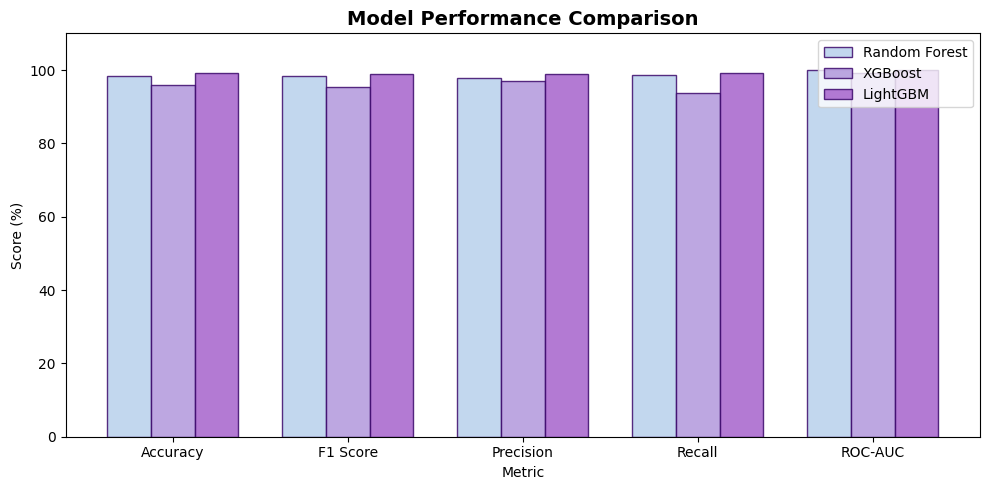

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']

x = np.arange(len(metrics))
width = 0.25
colors = ['#b8d0eb', '#b298dc', '#a663cc']
edgecolor = '#3c096c'

for i, (_, row) in enumerate(results_combined.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], edgecolor=edgecolor, alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("charts/model_comparison.png")
plt.show()

### Confusion Matrix

In [22]:
import seaborn as sns

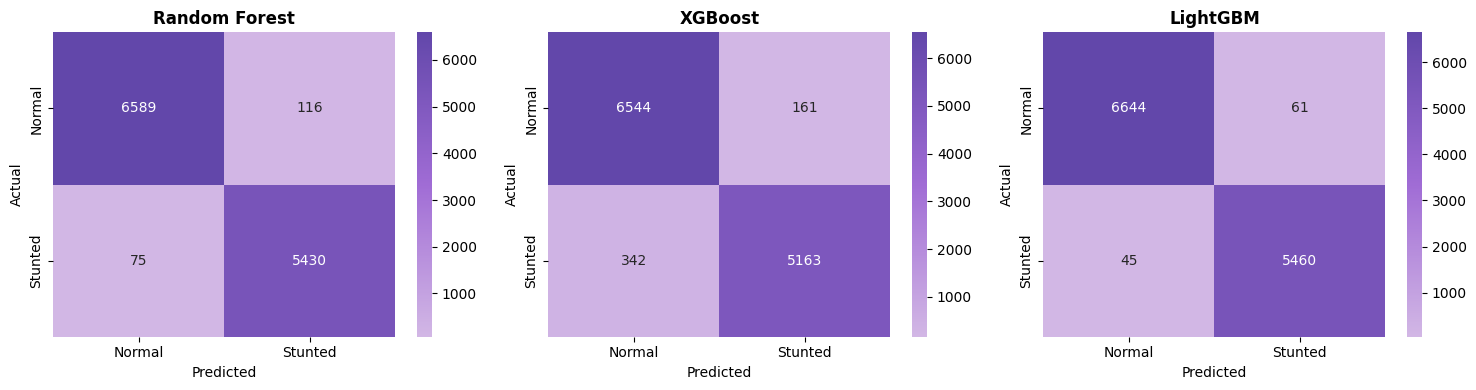

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

custom_cmap = LinearSegmentedColormap.from_list('custom', ['#d2b7e5', '#a06cd5', '#6247aa'])

models_info = [
    ('Random Forest', rf_pred),
    ('XGBoost', preds),
    ('LightGBM', y_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, ax=ax,
                xticklabels=['Normal', 'Stunted'],
                yticklabels=['Normal', 'Stunted'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png")
plt.show()